## Pippline
1. Load data → drop nulls (nst, dmin, errors columns)
2. Feature engineering → depth, lat, lon, days_since_last, avg_mag_1yr, distance_to_fault
3. Train/test split → temporal (2004-2023 train, 2024 test)
4. Train 5 models → Linear, Ridge, RF, GB, SVM
5. Evaluate → RMSE, MAE, R², residuals
6. Feature importance → which features matter?
7. Save best model → joblib
8. Ship → GitHub

In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from

linear,ridge,ef,gcv,svm

In [214]:
earthquake = pd.read_csv('../data/query.csv')

In [215]:
earthquake

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-03-29T05:24:22.120Z,30.2661,84.2330,10.0,4.4,mb,50.0,157.0,6.007,0.43,...,2026-04-09T11:17:47.040Z,"141 km NW of Saga, China",earthquake,12.07,1.927,0.088,37.0,reviewed,us,us
1,2026-03-29T03:14:38.812Z,27.1414,88.1012,10.0,4.5,mb,48.0,160.0,3.690,0.68,...,2026-04-09T00:29:41.760Z,"13 km W of Naya Bāzār, India",earthquake,9.68,1.905,0.080,45.0,reviewed,us,us
2,2026-03-12T07:45:48.786Z,28.9576,86.8579,10.0,4.5,mb,59.0,160.0,3.801,0.52,...,2026-04-02T11:55:13.040Z,"111 km N of Lobuche, Nepal",earthquake,8.36,2.466,0.071,58.0,reviewed,us,us
3,2026-02-26T11:52:12.168Z,27.3076,88.1070,10.0,4.3,mb,47.0,161.0,3.572,0.86,...,2026-03-25T13:04:27.496Z,"15 km W of Gyalshing, India",earthquake,10.42,1.907,0.090,35.0,reviewed,us,us
4,2026-02-26T06:04:05.847Z,27.2253,88.1573,10.0,4.8,mb,62.0,98.0,3.596,0.63,...,2026-03-18T07:07:47.475Z,"12 km SW of Gyalshing, India",earthquake,10.46,1.872,0.070,63.0,reviewed,us,us
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926,2004-06-30T15:33:04.410Z,29.8480,87.8710,25.1,4.3,mb,36.0,78.9,NaN,0.89,...,2014-11-07T01:22:44.482Z,"118 km NW of Rikaze, China",earthquake,NaN,17.200,NaN,9.0,reviewed,us,us
927,2004-06-26T02:59:28.540Z,30.0380,88.0520,56.8,4.2,mb,26.0,88.7,NaN,0.91,...,2014-11-07T01:22:41.598Z,"118 km NW of Rikaze, China",earthquake,NaN,8.800,NaN,2.0,reviewed,us,us
928,2004-06-24T10:03:28.600Z,29.8680,87.9050,20.0,4.3,mb,26.0,132.0,NaN,1.21,...,2014-11-07T01:22:41.001Z,"116 km NW of Rikaze, China",earthquake,NaN,0.000,NaN,7.0,reviewed,us,us
929,2004-05-29T12:22:15.630Z,28.5120,82.7020,25.0,4.1,mb,26.0,88.1,NaN,0.94,...,2014-11-07T01:22:25.816Z,"41 km NE of Besisahar, Nepal",earthquake,NaN,18.900,NaN,2.0,reviewed,us,us


In [216]:
earthquake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 931 entries, 0 to 930
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             931 non-null    object 
 1   latitude         931 non-null    float64
 2   longitude        931 non-null    float64
 3   depth            931 non-null    float64
 4   mag              931 non-null    float64
 5   magType          931 non-null    object 
 6   nst              439 non-null    float64
 7   gap              930 non-null    float64
 8   dmin             709 non-null    float64
 9   rms              927 non-null    float64
 10  net              931 non-null    object 
 11  id               931 non-null    object 
 12  updated          931 non-null    object 
 13  place            931 non-null    object 
 14  type             931 non-null    object 
 15  horizontalError  696 non-null    float64
 16  depthError       832 non-null    float64
 17  magError        

In [217]:
# check for duplicates 
earthquake.duplicated().sum()

0

In [218]:
# check for null values 
earthquake.isna().sum()

time                 0
latitude             0
longitude            0
depth                0
mag                  0
magType              0
nst                492
gap                  1
dmin               222
rms                  4
net                  0
id                   0
updated              0
place                0
type                 0
horizontalError    235
depthError          99
magError           229
magNst              31
status               0
locationSource       0
magSource            0
dtype: int64

In [219]:
# total dataset is of 921 rows, we should defenitley drop null values more than 50 
earthquake = earthquake.drop(['nst','dmin','horizontalError','depthError','magError','magNst'], axis=1)

In [220]:
earthquake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 931 entries, 0 to 930
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   time            931 non-null    object 
 1   latitude        931 non-null    float64
 2   longitude       931 non-null    float64
 3   depth           931 non-null    float64
 4   mag             931 non-null    float64
 5   magType         931 non-null    object 
 6   gap             930 non-null    float64
 7   rms             927 non-null    float64
 8   net             931 non-null    object 
 9   id              931 non-null    object 
 10  updated         931 non-null    object 
 11  place           931 non-null    object 
 12  type            931 non-null    object 
 13  status          931 non-null    object 
 14  locationSource  931 non-null    object 
 15  magSource       931 non-null    object 
dtypes: float64(6), object(10)
memory usage: 116.5+ KB


In [221]:
earthquake.sample(2)

,time,latitude,longitude,depth,mag,magType,gap,rms,net,id,updated,place,type,status,locationSource,magSource
747,2011-08-19T01:52:08.040Z,29.5480,81.5270,10.00,4.0,mb,127.7,1.03,us,usp000j6nq,2014-11-07T01:45:38.133Z,"65 km ENE of Dipayal, Nepal",earthquake,reviewed,us,us
377,2015-11-24T12:24:15.590Z,28.1552,84.7587,8.19,4.6,mb,60.0,0.96,us,us100040q1,2016-02-18T04:48:52.040Z,Nepal,earthquake,reviewed,us,us


In [222]:
earthquake = earthquake[['time', 'latitude', 'longitude', 'depth', 'gap', 'rms', 'mag']]

In [223]:
earthquake

,time,latitude,longitude,depth,gap,rms,mag
0,2026-03-29T05:24:22.120Z,30.2661,84.2330,10.0,157.0,0.43,4.4
1,2026-03-29T03:14:38.812Z,27.1414,88.1012,10.0,160.0,0.68,4.5
2,2026-03-12T07:45:48.786Z,28.9576,86.8579,10.0,160.0,0.52,4.5
3,2026-02-26T11:52:12.168Z,27.3076,88.1070,10.0,161.0,0.86,4.3
4,2026-02-26T06:04:05.847Z,27.2253,88.1573,10.0,98.0,0.63,4.8
...,...,...,...,...,...,...,...
926,2004-06-30T15:33:04.410Z,29.8480,87.8710,25.1,78.9,0.89,4.3
927,2004-06-26T02:59:28.540Z,30.0380,88.0520,56.8,88.7,0.91,4.2
928,2004-06-24T10:03:28.600Z,29.8680,87.9050,20.0,132.0,1.21,4.3
929,2004-05-29T12:22:15.630Z,28.5120,82.7020,25.0,88.1,0.94,4.1


In [224]:
earthquake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 931 entries, 0 to 930
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   time       931 non-null    object 
 1   latitude   931 non-null    float64
 2   longitude  931 non-null    float64
 3   depth      931 non-null    float64
 4   gap        930 non-null    float64
 5   rms        927 non-null    float64
 6   mag        931 non-null    float64
dtypes: float64(6), object(1)
memory usage: 51.0+ KB


In [225]:
# EDA 

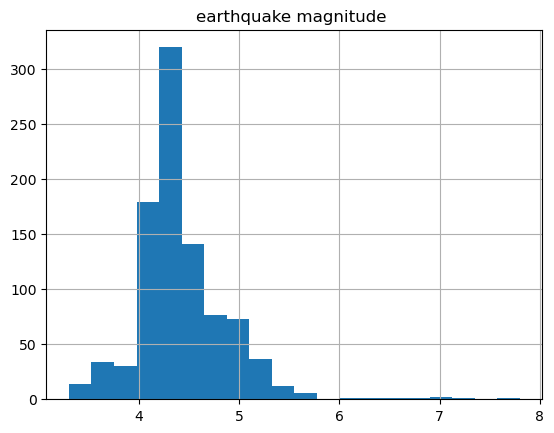

In [226]:
earthquake['mag'].hist(bins=20)
plt.title("earthquake magnitude ")
plt.show()

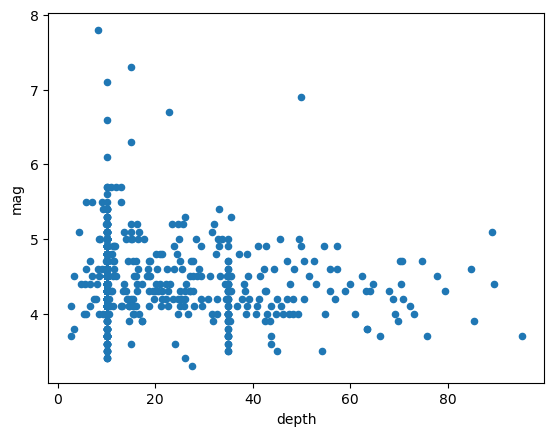

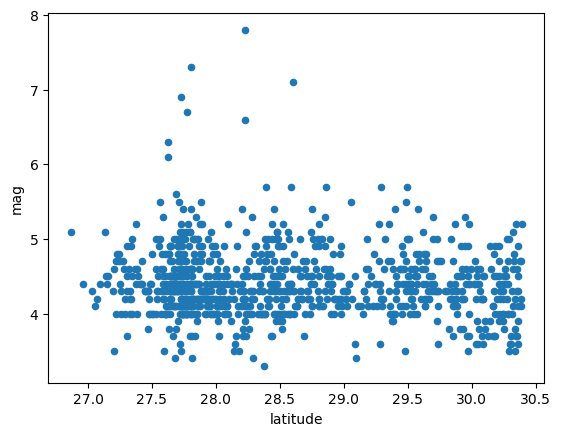

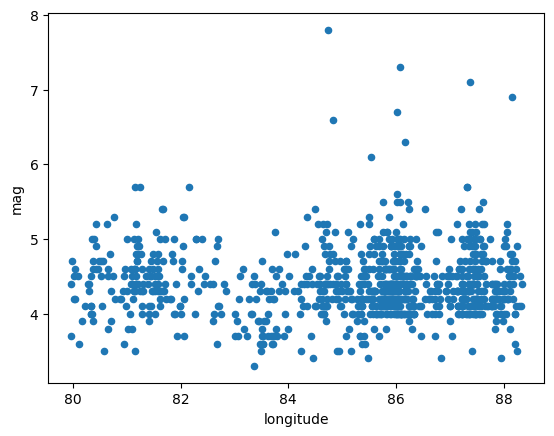

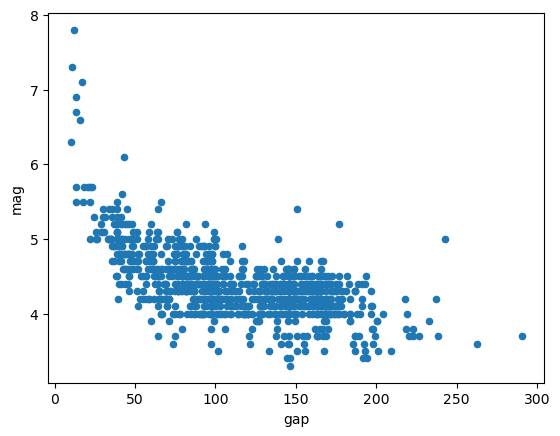

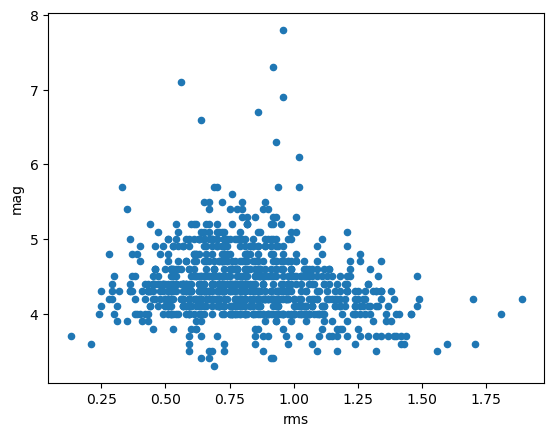

In [227]:

df.plot(x='depth', y='mag', kind='scatter')
df.plot(x='latitude', y='mag', kind='scatter')
df.plot(x='longitude', y='mag', kind='scatter')
df.plot(x='gap', y='mag', kind='scatter')
df.plot(x='rms', y='mag', kind='scatter')
plt.show()


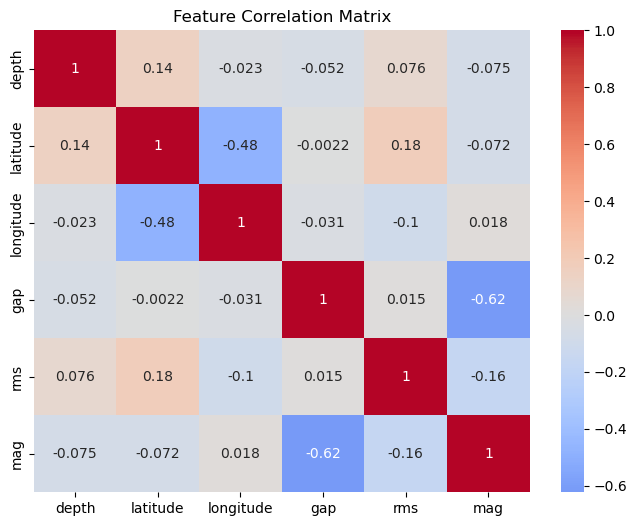

In [228]:
corr = df[['depth', 'latitude', 'longitude', 'gap', 'rms', 'mag']].corr()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()



In [229]:
# depth: -0.075 (almost no correlation)
# latitude: -0.072 (almost no correlation)
# longitude: 0.018 (almost no correlation)
# gap: -0.62 (STRONG negative correlation) 
# rms: -0.16 (weak negative correlation)

In [230]:
# Data Cleaning 
earthquake['time']


0      2026-03-29T05:24:22.120Z
1      2026-03-29T03:14:38.812Z
2      2026-03-12T07:45:48.786Z
3      2026-02-26T11:52:12.168Z
4      2026-02-26T06:04:05.847Z
                 ...           
926    2004-06-30T15:33:04.410Z
927    2004-06-26T02:59:28.540Z
928    2004-06-24T10:03:28.600Z
929    2004-05-29T12:22:15.630Z
930    2004-05-29T12:09:38.870Z
Name: time, Length: 931, dtype: object

In [231]:
earthquake.time = pd.to_datetime(earthquake['time'])

In [232]:
earthquake

,time,latitude,longitude,depth,gap,rms,mag
0,2026-03-29 05:24:22.120000+00:00,30.2661,84.2330,10.0,157.0,0.43,4.4
1,2026-03-29 03:14:38.812000+00:00,27.1414,88.1012,10.0,160.0,0.68,4.5
2,2026-03-12 07:45:48.786000+00:00,28.9576,86.8579,10.0,160.0,0.52,4.5
3,2026-02-26 11:52:12.168000+00:00,27.3076,88.1070,10.0,161.0,0.86,4.3
4,2026-02-26 06:04:05.847000+00:00,27.2253,88.1573,10.0,98.0,0.63,4.8
...,...,...,...,...,...,...,...
926,2004-06-30 15:33:04.410000+00:00,29.8480,87.8710,25.1,78.9,0.89,4.3
927,2004-06-26 02:59:28.540000+00:00,30.0380,88.0520,56.8,88.7,0.91,4.2
928,2004-06-24 10:03:28.600000+00:00,29.8680,87.9050,20.0,132.0,1.21,4.3
929,2004-05-29 12:22:15.630000+00:00,28.5120,82.7020,25.0,88.1,0.94,4.1


In [233]:
earthquake['year'] = earthquake['time'].dt.year 
earthquake['month'] = earthquake['time'].dt.month
earthquake['day_of_year'] = earthquake['time'].dt.dayofyear


In [234]:
earthquake

,time,latitude,longitude,depth,gap,rms,mag,year,month,day_of_year
0,2026-03-29 05:24:22.120000+00:00,30.2661,84.2330,10.0,157.0,0.43,4.4,2026,3,88
1,2026-03-29 03:14:38.812000+00:00,27.1414,88.1012,10.0,160.0,0.68,4.5,2026,3,88
2,2026-03-12 07:45:48.786000+00:00,28.9576,86.8579,10.0,160.0,0.52,4.5,2026,3,71
3,2026-02-26 11:52:12.168000+00:00,27.3076,88.1070,10.0,161.0,0.86,4.3,2026,2,57
4,2026-02-26 06:04:05.847000+00:00,27.2253,88.1573,10.0,98.0,0.63,4.8,2026,2,57
...,...,...,...,...,...,...,...,...,...,...
926,2004-06-30 15:33:04.410000+00:00,29.8480,87.8710,25.1,78.9,0.89,4.3,2004,6,182
927,2004-06-26 02:59:28.540000+00:00,30.0380,88.0520,56.8,88.7,0.91,4.2,2004,6,178
928,2004-06-24 10:03:28.600000+00:00,29.8680,87.9050,20.0,132.0,1.21,4.3,2004,6,176
929,2004-05-29 12:22:15.630000+00:00,28.5120,82.7020,25.0,88.1,0.94,4.1,2004,5,150


In [235]:
def feature_engineering(df):
    df = df.sort_values('time').reset_index(drop=True)
    df['days_since_last'] = df['time'].diff().dt.days.fillna(0)
    df['avg_mag_1yr'] = df['mag'].rolling(window=365, min_periods=1).mean()
    
    fault_lat, fault_lon = 28.0, 84.0
    df['dist_to_fault'] = np.sqrt((df['latitude'] - fault_lat)**2 + (df['longitude'] - fault_lon)**2)
    
    return df

In [236]:
earthquake = earthquake.dropna()

In [237]:
earthquake = feature_engineering(earthquake)


In [239]:
earthquake = earthquake.drop(['time'], axis=1)


In [240]:
earthquake

,latitude,longitude,depth,gap,rms,mag,year,month,day_of_year,days_since_last,avg_mag_1yr,dist_to_fault
0,28.5000,82.6070,31.8,126.9,0.64,3.9,2004,5,150,0.0,3.900000,1.480017
1,28.5120,82.7020,25.0,88.1,0.94,4.1,2004,5,150,0.0,4.000000,1.395331
2,29.8680,87.9050,20.0,132.0,1.21,4.3,2004,6,176,25.0,4.100000,4.328793
3,30.0380,88.0520,56.8,88.7,0.91,4.2,2004,6,178,1.0,4.125000,4.535653
4,29.8480,87.8710,25.1,78.9,0.89,4.3,2004,6,182,4.0,4.160000,4.289492
...,...,...,...,...,...,...,...,...,...,...,...,...
922,27.2253,88.1573,10.0,98.0,0.63,4.8,2026,2,57,16.0,4.459178,4.228865
923,27.3076,88.1070,10.0,161.0,0.86,4.3,2026,2,57,0.0,4.459726,4.164957
924,28.9576,86.8579,10.0,160.0,0.52,4.5,2026,3,71,13.0,4.457808,3.014065
925,27.1414,88.1012,10.0,160.0,0.68,4.5,2026,3,88,16.0,4.458904,4.190112


mag                1.000000
year               0.184033
avg_mag_1yr        0.148451
dist_to_fault      0.026833
longitude          0.018449
days_since_last   -0.023187
day_of_year       -0.028872
month             -0.031350
latitude          -0.072235
depth             -0.074578
rms               -0.162904
gap               -0.622840
Name: mag, dtype: float64


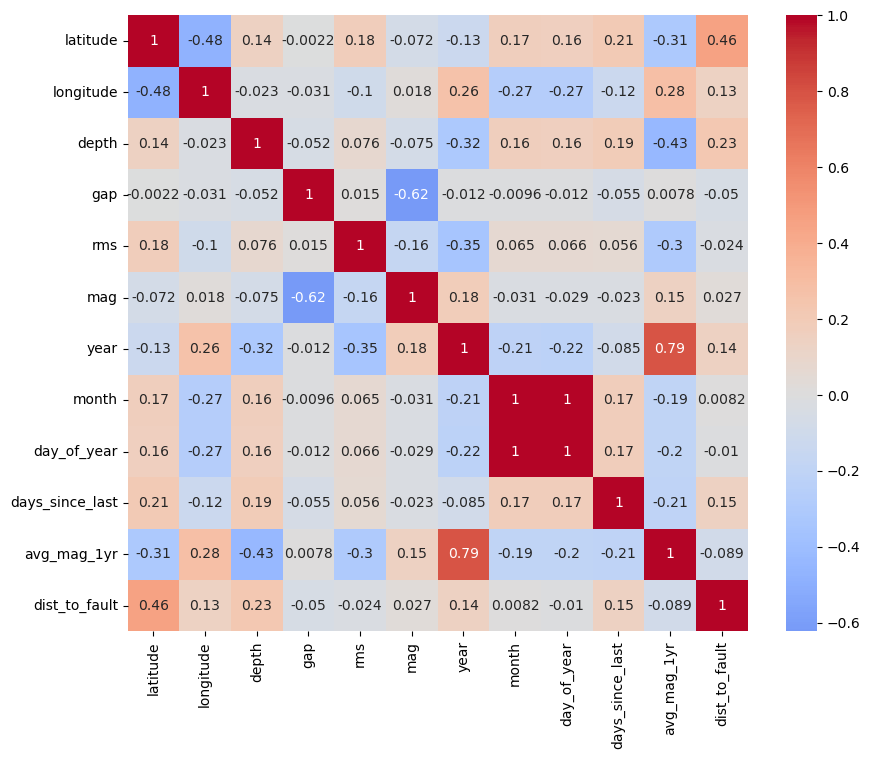

In [241]:
# Correlation with magnitude
corr_with_mag = earthquake.corr()['mag'].sort_values(ascending=False)
print(corr_with_mag)

# Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(earthquake.corr(), annot=True, cmap='coolwarm', center=0)
plt.show()

In [243]:
# gap: -0.62 (strong negative) 
# year: 0.18
# avg_mag_1yr: 0.15
# dist_to_fault: 0.027 (very weak)
# days_since_last: -0.023 (almost none)
# depth: -0.075
# latitude: -0.072
# longitude: 0.018
# month: -0.031
# day_of_year: -0.029
# rms: -0.16


# gap is still the strongest (-0.62)
# Engineered features are weak:

# avg_mag_1yr: 0.15 (barely helps)
# days_since_last: -0.023 (useless)
# dist_to_fault: 0.027 (useless)


# year correlates 0.18 (temporal trend exists)



In [244]:
# dropping weak realtion data 

In [247]:
earthquake = earthquake.drop(['days_since_last', 'avg_mag_1yr', 'dist_to_fault', 'day_of_year'], axis=1)

mag          1.000000
year         0.184033
longitude    0.018449
month       -0.031350
latitude    -0.072235
depth       -0.074578
rms         -0.162904
gap         -0.622840
Name: mag, dtype: float64


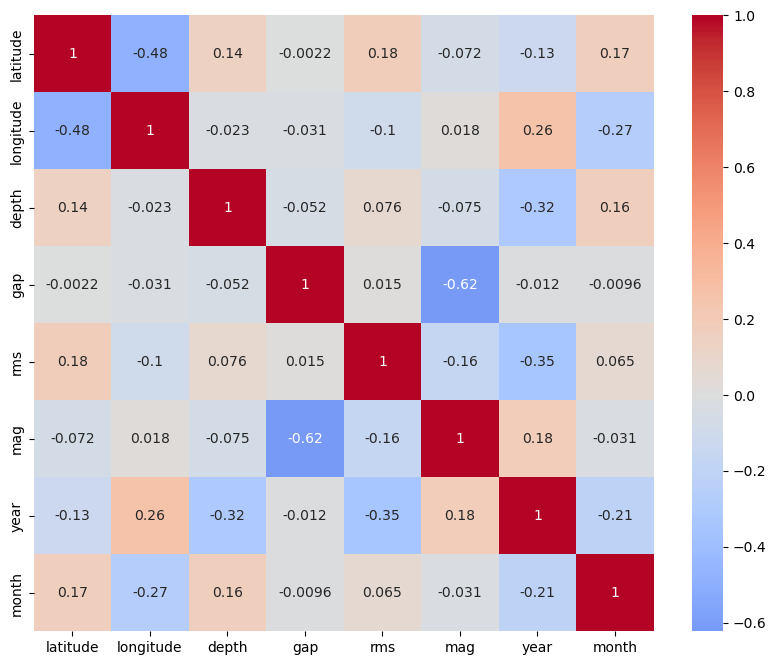

In [248]:
# Correlation with magnitude
corr_with_mag = earthquake.corr()['mag'].sort_values(ascending=False)
print(corr_with_mag)

# Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(earthquake.corr(), annot=True, cmap='coolwarm', center=0)
plt.show()